In [1]:
# Import module constrained_likelihood_surrogates
#
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

In [2]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import binned_statistic#For binning points to show median and confidence intervals
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

line_style_list = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
marker_list = ['s', 'd', 'o', '|', '_', '+', 'x', '1', '2', '3', '4', '*', '8', 'p']

load_folder_name = './results/hyp-test/words/'

process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
method_list = ['constrained', 'typical', 'sign', 'CLT']
num_methods = len(method_list)

In [3]:
import pickle
with open("../data/words/dataBeagle1000.pkl","rb") as f:
    dictR = pickle.load(f)
with open("../data/words/countBeagle1000.pkl","rb") as f:
    dictC = pickle.load(f)
with open("../data/words/burstinessBeagle1000.pkl","rb") as f:
    dictB = pickle.load(f)
word1000_list = list(dictR.keys())
burstiness1000list = [float(s) for s in dictB.values()]
num_words1000 = len(word1000_list)

In [4]:
# # Load results: hypothesis testing

test_type = 'rejection'

load_folder_name = './results/hyp-test/words/'

# lower_cutoff = 4.5
lower_cutoff = 9.5#Main text
# lower_cutoff = 19.5

num_surr = 999#Manuscript

num_tests = 10**0
# num_free_stats, num_depe_stats = 12, 3
num_free_stats, num_depe_stats = 12, 7
model = 'expon'
model_list = [model]
num_models = len(model_list)
method_list = ['constrained', 'typical']
num_methods = len(method_list)

word_list = []
for i_word1000 in range(num_words1000):
    word = word1000_list[i_word1000]
    save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_mod-' + str(model) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    process_str = '_wait-seq-' + word
    save_str = save_str_0 + process_str
    if not exists(load_folder_name + save_str + '.json'):
        continue
    else:
        word_list = word_list + [word]
num_words = len(word_list)
        
free_quantile_mat = np.zeros((num_words, num_methods, num_models, num_tests, num_free_stats))
depe_quantile_mat = np.zeros((num_words, num_methods, num_models, num_tests, num_depe_stats))
N_list = []
count_list = []
burstiness_list = []

for i_word in range(num_words):
    word = word_list[i_word]
    save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_mod-' + str(model) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
    process_str = '_wait-seq-' + word
    save_str = save_str_0 + process_str
    with open(load_folder_name + save_str + '.json', 'r') as read_file:
        save_dict = json.load(read_file)
    
    free_quantile_list_list = np.array(save_dict['free_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_free_stats
    free_quantile_mat[i_word, :, :, :, :] = free_quantile_list_list# num_N x num_methods x num_models x num_tests x num_free_stats
    
    depe_quantile_list_list = np.array(save_dict['depe_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_depe_stats
    depe_quantile_mat[i_word, :, :, :, :] = depe_quantile_list_list# num_N x num_methods x num_models x num_tests x num_depe_stats
    
    count = save_dict['count']
    burstiness = save_dict['burstiness']
    N = save_dict['N']
    count_list = count_list + [count]
    burstiness_list = burstiness_list + [float(burstiness)]
    N_list = N_list + [N]
    
    num_trans = save_dict['num_trans']
    save_str = save_dict['save_str']
    total_time = save_dict['total_time']
    val_seq = save_dict['val_seq']
    val_seq_full = save_dict['val_seq_full']
    word = save_dict['word']
    
test_type = save_dict['test_type']
lower_cutoff = save_dict['lower_cutoff']
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_str = save_dict['process_str']
model = save_dict['model']
model_list = save_dict['model_list']
free_stat_name_list = save_dict['free_stat_name_list']
depe_stat_name_list = save_dict['depe_stat_name_list']

nominal_size = 0.10

Lower cut-off: 9.5
29 word(s) with N=30: ['tame', 'magellan', 'interest', 'watch', 'use', 'sure', 'support', 'successive', 'strait', 'showed', 'sandstone', 'riding', 'regions', 'purpose', 'prey', 'peru', 'noticed', 'la', 'feeling', 'completely', 'collected', 'cliff', 'chapter', 'brown', 'brazil', 'australia', 'andes', 'ancient', 'absolutely']
Inset shows 614 words


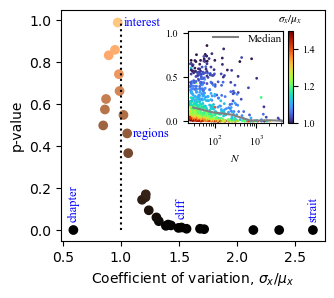

In [5]:
# # One-panel plot

# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# stat_type = 'free'
# stat_type = 'depe'

# side = 'left-tailed'
# side = 'right-tailed'
# side = 'two-sided'

# stat_type = 'depe'; side = 'two-sided'
# stat_type = 'depe'; side = 'right-tailed'
# stat_type = 'depe'; side = 'left-tailed'

stat_type = 'free'; side = 'two-sided'
# stat_type = 'free'; side = 'right-tailed'
# stat_type = 'free'; side = 'left-tailed'

i_method = 0#Constrained
# i_method = 0#Typical

method = method_list[i_method]

if (stat_type == 'free'):
    stat_name_list = free_stat_name_list
    quantile_mat = free_quantile_mat
elif (stat_type == 'depe'):
    stat_name_list = depe_stat_name_list
    quantile_mat = depe_quantile_mat
num_stats = len(stat_name_list)

if (side == 'left-tailed'):
    rej_mat = (quantile_mat < nominal_size)# num_words x num_methods x num_models x num_tests x num_stats
    p_mat = quantile_mat# num_words x num_methods x num_models x num_tests x num_stats
elif (side == 'right-tailed'):
    rej_mat = (quantile_mat > (1 - nominal_size))# num_words x num_methods x num_models x num_tests x num_stats
    p_mat = 1 - quantile_mat# num_words x num_methods x num_models x num_tests x num_stats
elif (side == 'two-sided'):
    rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
    p_mat = 2*np.minimum(quantile_mat, 1 - quantile_mat)# num_words x num_methods x num_models x num_tests x num_stats
    
rej_rate_mat = np.sum(rej_mat, axis=3)/num_tests# num_words x num_methodsx num_models x num_stats
std_rej_rate_mat = np.std(rej_mat, axis=3, ddof=0)# num_words x num_methods x num_models x num_stats

mean_quantile_mat = np.mean(quantile_mat, axis=3)# num_words x num_methods x num_models x num_stats
mean_p_mat = np.mean(p_mat, axis=3)# num_words x num_methods x num_models x num_stats

# RATE OF REJECTION:
i_model = 0
model = model_list[i_model]

# # p-value versus burstiness for fixed N:

N = 30#Focus on N=30 (above lower cutoff)
N_list_2 = [N_list[i_word] for i_word in range(num_words) if (N_list[i_word] == N)]
word_list_2 = [word_list[i_word] for i_word in range(num_words) if (N_list[i_word] == N)]
burstiness_list_2 = [float(burstiness_list[i_word]) for i_word in range(num_words) if (N_list[i_word] == N)]

cmap = "copper"

print(f'Lower cut-off: {lower_cutoff}')
print(f'{len(N_list_2)} word(s) with N={N}: {list(word_list_2)}')

# # p-value versus N, colour-coded according to burstiness:

# Log bins in N:
num_bins = 6;
log_bins = 2**np.linspace(np.log2(min(N_list)) - 0.5, np.log2(max(N_list)) + 0.5, num_bins + 1)
log_bin_centres = np.sqrt(log_bins[:-1]*log_bins[1:])  # Geometric mean for bin centers

burstiness_range = [1, 1.5]
# cmap_2 = "nipy_spectral"
# cmap_2 = "gist_ncar"
# cmap_2 = "jet"
cmap_2 = "turbo"
s = 1#Marker size


# # Plotting:

for i_stat in [6]:#Coefficient of variation only
# for i_stat in range(num_stats):
    stat = stat_name_list[i_stat]
    # rej_rate_list = rej_rate_mat[:, i_method, i_model, i_stat]
    # err_list = std_rej_rate_mat[:, i_method, i_model, i_stat]/np.sqrt(num_tests)
    mean_quantile_list = mean_quantile_mat[:, i_method, i_model, i_stat]
    mean_p_list = mean_p_mat[:, i_method, i_model, i_stat]
    
    fig, ax0 = plt.subplots(1, 1, figsize=(3.4, 3))

    base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
    label_font_size = 1.0*base_font_size;
    
    # # Main panel: p-value versus burstiness for fixed N:
    
    ax = ax0
    mean_p_list_2 = [mean_p_list[i_word] for i_word in range(num_words) if (N_list[i_word] == N)]
    sc = ax.scatter(burstiness_list_2, mean_p_list_2, c=mean_p_list_2, cmap=cmap)
    vplot, = ax.plot([1, 1], [0, 1], 'k:', label='burstiness=1')
    for word in ['chapter', 'cliff', 'strait', 'interest', 'regions']:
        i_word_2 = word_list_2.index(word)
        word = word_list_2[i_word_2]
        burstiness = burstiness_list_2[i_word_2]
        mean_p = mean_p_list_2[i_word_2]
        if (mean_p < 0.1):
            ax.text(burstiness, mean_p + 0.04, word, color='blue', rotation='vertical', va='bottom', ha='center')
        else:
            ax.text(burstiness + 0.05, mean_p, word, color='blue', rotation='horizontal', va='center', ha='left')
    ax.set_ylabel('p-value')
    ax.set_xlabel('Coefficient of variation, $\sigma_x/\mu_x$')
    # ax.set_title('$N=' + str(N) + '$')
    ax.set_ylim([-0.05, 1.05])
    # # Add colourbar
    # divider = make_axes_locatable(ax)
    # cax = divider.append_axes("right", size="5%", pad=0.1)
    # fig.colorbar(sc, cax=cax)
    # cax.set_title('p-value', fontsize='medium')

    
    # # Inset: p-value versus N, colour-coded according to burstiness:

    lb = burstiness_range[0]
    ub = burstiness_range[1]

    word_list_2 = [word_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
    N_list_2 = [N_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
    mean_p_list_2 = [mean_p_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
    burstiness_list_2 = [burstiness_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
    
    # Inset:
    inset_length = 0.40
    ax = ax0.inset_axes([1 - (inset_length + 0.12), 1 - (inset_length + 0.09), inset_length, inset_length])
    
    # sc = ax.scatter(N_list_2, mean_p_list_2, c=np.log(np.array(burstiness_list_2)), cmap=cmap_2, s=s, vmin=vmin, vmax=vmax)
    # sc = ax.scatter(N_list_2, mean_p_list_2, s=s, c='k', vmin=vmin, vmax=vmax)
    sc = ax.scatter(N_list_2, mean_p_list_2, c=burstiness_list_2, cmap=cmap_2, s=s, vmin=lb, vmax=ub)
    # Calculate statistics for each log-bin
    alpha = 0.5# 1 - alpha confidence intervals
    median, _, _ = binned_statistic(N_list_2, mean_p_list_2, statistic='median', bins=log_bins)
    mplot, = ax.plot(log_bin_centres, median, '-', color='gray', label='Median')
    ax.set_xscale('log')
    ax.set_xlabel('$N$')
    # ax.set_title('burstiness$\in[' + str(lb) + ',' + str(ub) + ']$', fontsize='medium')
    ax.set_ylim([-0.02, 1.03])
    ax.set_xlim([0.90*min(N_list_2), 1.1*max(N_list_2)])
    # ax.legend(handles=[mplot], ncol=2, loc='upper right')
    # ax.legend(handles=[mplot], ncol=2, loc='lower right', bbox_to_anchor=(1, -0.8))
    ax.legend(handles=[mplot], ncol=2, loc='upper right', frameon=False, bbox_to_anchor=(1.1, 1.1))
    set_inset_fonts(ax)

    # cax = inset_axes(ax, width="6%", height="100%", loc="lower left", bbox_to_anchor=(1.05, 0.0, 1.0, 1.0), bbox_transform=ax.transAxes, borderpad=0)
    # cbar = fig.colorbar(sc, cax=cax, orientation='vertical')
    # cbar.ax.set_title('Coef. var.')
    # if hasattr(cbar, "solids") and cbar.solids is not None:
    #     cbar.solids.set_rasterized(True)
    # set_inset_fonts(cax)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="6%", pad=0.04)
    cbar = fig.colorbar(sc, cax=cax, orientation='vertical')
    cbar.ax.set_title('$\sigma_x/\mu_x$')
    
    eps = 1e-9 * (ub - lb)
    sc.set_clim(lb - eps, ub + eps)
    
    # Force the colorbar to refresh and fill its axis properly
    cbar.update_normal(sc)
    cbar.ax.margins(y=0)
    
    # Optional PDF-safe fixes
    if getattr(cbar, "solids", None) is not None:
        cbar.solids.set_edgecolor("face")
        cbar.solids.set_rasterized(True)
    
    set_inset_fonts(cax)
    
    fig_name_str = 'p-vs-burstiness-and-p-vs-N-from-' + stat + '_' + side + '_words_1'
    # plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    # plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')

    # ax0.set_title('$x_{\min}=' + f'{lower_cutoff}$, ${num_surr}$ surrogates')
    plt.savefig('figures\\' + fig_name_str + f'_xmin-{lower_cutoff}_nsurr-{num_surr}' + '.png', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + f'_xmin-{lower_cutoff}_nsurr-{num_surr}' + '.pdf', bbox_inches='tight')

    print(f'Inset shows {len(word_list_2)} words')
    
    plt.show()

614 words shown
169 words shown
1000 words shown


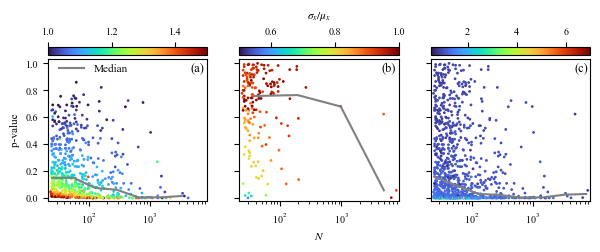

In [6]:
# # three panel showing p-value vs N for different ranges of burstiness

# process_list: ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']

# stat_type = 'free'
# stat_type = 'depe'

# side = 'left-tailed'
# side = 'right-tailed'
# side = 'two-sided'

# stat_type = 'depe'; side = 'two-sided'
# stat_type = 'depe'; side = 'right-tailed'
# stat_type = 'depe'; side = 'left-tailed'

stat_type = 'free'; side = 'two-sided'
# stat_type = 'free'; side = 'right-tailed'
# stat_type = 'free'; side = 'left-tailed'

i_method = 0#Constrained
# i_method = 0#Typical

method = method_list[i_method]

if (stat_type == 'free'):
    stat_name_list = free_stat_name_list
    quantile_mat = free_quantile_mat
elif (stat_type == 'depe'):
    stat_name_list = depe_stat_name_list
    quantile_mat = depe_quantile_mat
num_stats = len(stat_name_list)

if (side == 'left-tailed'):
    rej_mat = (quantile_mat < nominal_size)# num_words x num_methods x num_models x num_tests x num_stats
    p_mat = quantile_mat# num_words x num_methods x num_models x num_tests x num_stats
elif (side == 'right-tailed'):
    rej_mat = (quantile_mat > (1 - nominal_size))# num_words x num_methods x num_models x num_tests x num_stats
    p_mat = 1 - quantile_mat# num_words x num_methods x num_models x num_tests x num_stats
elif (side == 'two-sided'):
    rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
    p_mat = 2*np.minimum(quantile_mat, 1 - quantile_mat)# num_words x num_methods x num_models x num_tests x num_stats
    
rej_rate_mat = np.sum(rej_mat, axis=3)/num_tests# num_words x num_methodsx num_models x num_stats
std_rej_rate_mat = np.std(rej_mat, axis=3, ddof=0)# num_words x num_methods x num_models x num_stats

mean_quantile_mat = np.mean(quantile_mat, axis=3)# num_words x num_methods x num_models x num_stats
mean_p_mat = np.mean(p_mat, axis=3)# num_words x num_methods x num_models x num_stats

# RATE OF REJECTION:
i_model = 0
model = model_list[i_model]

# # p-value versus burstiness for fixed N:

N = 30#Focus on N=30 (above lower cutoff)
N_list_2 = [N_list[i_word] for i_word in range(num_words) if (N_list[i_word] == N)]
word_list_2 = [word_list[i_word] for i_word in range(num_words) if (N_list[i_word] == N)]
burstiness_list_2 = [float(burstiness_list[i_word]) for i_word in range(num_words) if (N_list[i_word] == N)]

cmap = "copper"

# # p-value versus N, colour-coded according to burstiness:

num_col = 3

burstiness_range_list = [[1, 1.5], [0.5, 1], [0.5, 7]]
# cmap_2 = "nipy_spectral"
# cmap_2 = "gist_ncar"
# cmap_2 = "jet"
cmap_2 = "turbo"
s = 1#Marker size

num_bins_list = [8, 4, 8];

# # Plotting:

for i_stat in [6]:#Coefficient of variation only
# for i_stat in range(num_stats):
    stat = stat_name_list[i_stat]
    # rej_rate_list = rej_rate_mat[:, i_method, i_model, i_stat]
    # err_list = std_rej_rate_mat[:, i_method, i_model, i_stat]/np.sqrt(num_tests)
    mean_quantile_list = mean_quantile_mat[:, i_method, i_model, i_stat]
    mean_p_list = mean_p_mat[:, i_method, i_model, i_stat]
    
    fig, ax_list = plt.subplots(1, num_col, figsize=(7, 2), sharex=True, sharey=True)

    base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
    label_font_size = 1.0*base_font_size;
    
    # # Main panel: p-value versus burstiness for fixed N:

    for i_col in range(num_col):
            
        # # Inset: p-value versus N, colour-coded according to burstiness:

        burstiness_range = burstiness_range_list[i_col]
        lb = burstiness_range[0]
        ub = burstiness_range[1]
        
        # Log bins in N:
        num_bins = num_bins_list[i_col]
        log_bins = 2**np.linspace(np.log2(min(N_list)) - 0.5, np.log2(max(N_list)) + 0.5, num_bins + 1)
        log_bin_centres = np.sqrt(log_bins[:-1]*log_bins[1:])  # Geometric mean for bin centers
    
        word_list_2 = [word_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
        N_list_2 = [N_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
        mean_p_list_2 = [mean_p_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
        burstiness_list_2 = [burstiness_list[i_word] for i_word in range(num_words) if ((burstiness_list[i_word] >= lb) and (burstiness_list[i_word] < ub))]
        
        # Inset:
        inset_length = 0.40
        ax = ax_list[i_col]
        
        # sc = ax.scatter(N_list_2, mean_p_list_2, c=np.log(np.array(burstiness_list_2)), cmap=cmap_2, s=s, vmin=vmin, vmax=vmax)
        # sc = ax.scatter(N_list_2, mean_p_list_2, s=s, c='k', vmin=vmin, vmax=vmax)
        sc = ax.scatter(N_list_2, mean_p_list_2, c=burstiness_list_2, cmap=cmap_2, s=s, vmin=lb, vmax=ub)
        # Calculate statistics for each log-bin
        alpha = 0.5# 1 - alpha confidence intervals
        median, _, _ = binned_statistic(N_list_2, mean_p_list_2, statistic='median', bins=log_bins)
        mplot, = ax.plot(log_bin_centres, median, '-', color='gray', label='Median')
        ax.set_xscale('log')
        if (2*i_col + 1 == num_col):
            ax.set_xlabel('$N$')
        if (i_col == 0):
            ax.set_ylabel('p-value')
        # ax.set_title('burstiness$\in[' + str(lb) + ',' + str(ub) + ']$', fontsize='medium')
        ax.set_ylim([-0.02, 1.03])
        ax.set_xlim([0.90*min(N_list_2), 1.1*max(N_list_2)])
        # ax.legend(handles=[mplot], ncol=2, loc='upper right')
        # ax.legend(handles=[mplot], ncol=2, loc='lower right', bbox_to_anchor=(1, -0.8))
        if (i_col == 0):
            ax.legend(handles=[mplot], ncol=2, loc='upper left', frameon=False, bbox_to_anchor=(0, 1.05))
        set_inset_fonts(ax)
    
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("top", size="6%", pad=0.04)
        cbar = fig.colorbar(sc, cax=cax, orientation='horizontal')
        cbar.ticklocation = 'top'
        if (2*i_col + 1 == num_col):
            cbar.ax.set_title('$\sigma_x/\mu_x$')
        
        eps = 1e-9 * (ub - lb)
        sc.set_clim(lb - eps, ub + eps)
        
        # Force the colorbar to refresh and fill its axis properly
        cbar.update_normal(sc)
        cbar.ax.margins(y=0)
        
        # Optional PDF-safe fixes
        if getattr(cbar, "solids", None) is not None:
            cbar.solids.set_edgecolor("face")
            cbar.solids.set_rasterized(True)
        
        set_inset_fonts(cax)

        print(f'{len(word_list_2)} words shown')

    label_subplots(ax_list, corner='upper right')
    
    fig_name_str = 'p-vs-burstiness-and-p-vs-N-from-' + stat + '_' + side + '_words_3'
    plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')
    plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
    
    plt.show()